In [ ]:
!pip install torch-geometric rdkit networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 30.0 MB/s eta 0:00:00


#Import biblioteka

In [ ]:
import torch
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_smiles
from rdkit import Chem
from rdkit.Chem import Draw
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Priprema podataka - SMILES u grafove

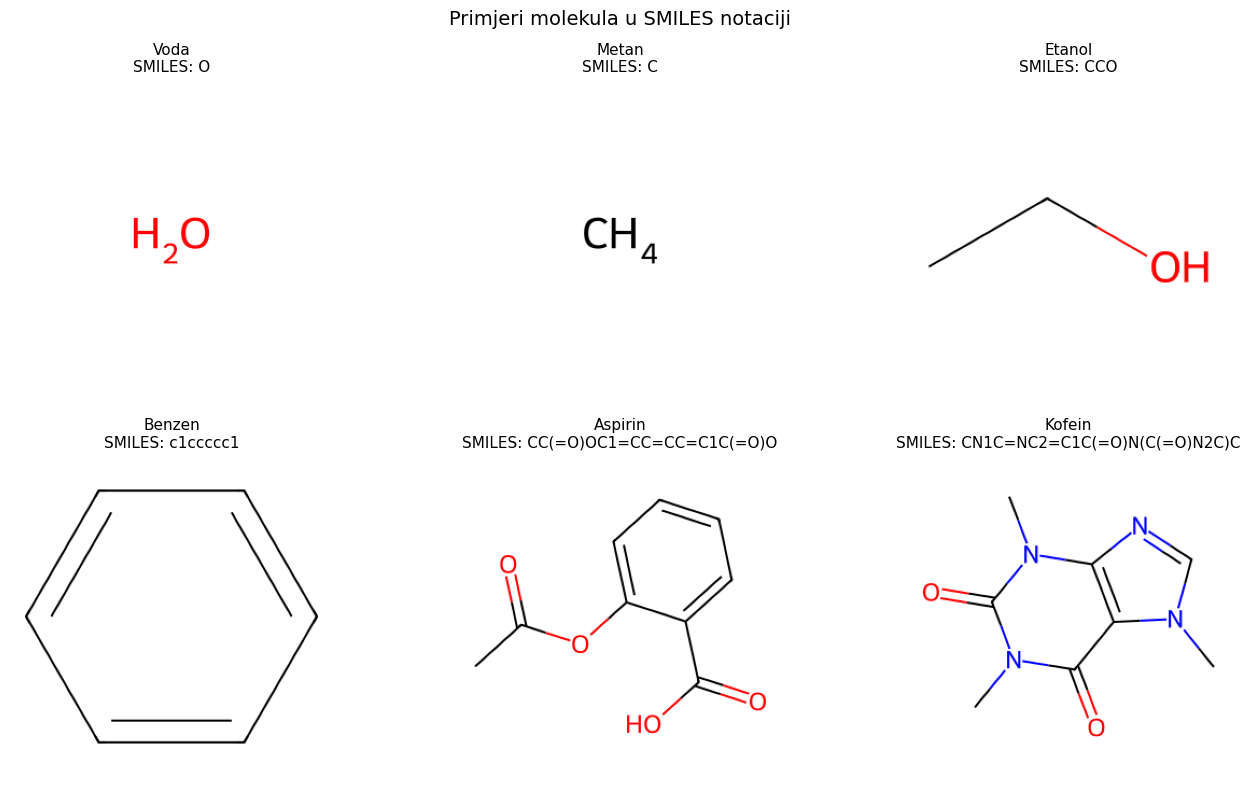

In [ ]:
primjeri = {
    'Voda': 'O',
    'Metan': 'C',
    'Etanol': 'CCO',
    'Benzen': 'c1ccccc1',
    'Aspirin': 'CC(=O)OC1=CC=CC=C1C(=O)O',
    'Kofein': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (ime, smiles) in zip(axes.flatten(), primjeri.items()):
    mol = Chem.MolFromSmiles(smiles)
    img = Draw.MolToImage(mol, size=(300, 300))
    ax.imshow(img)
    ax.set_title(f"{ime}\nSMILES: {smiles}", fontsize=11)
    ax.axis('off')

plt.suptitle('Primjeri molekula u SMILES notaciji', fontsize=14)
plt.tight_layout()
plt.show()

##Pretvorba SMILES u graf

In [ ]:
smiles = 'CCO'
graph = from_smiles(smiles)

print(f'SMILES: {smiles}')
print(f'Graf: {graph}')
print()
print(f'Broj atoma (čvorova): {graph.x.size(0)}')
print(f'Broj dimenzija značajki po atomu: {graph.x.size(1)}')
print(f'Broj veza (bridova, dvosmjerno): {graph.edge_index.size(1)}')
print(f'Broj dimenzija značajki po vezi: {graph.edge_attr.size(1)}')
print()
print('Značajke atoma:')
print(graph.x)
print()
print('Veza:')
print(graph.edge_index)
print()
print('Značajke veza:')
print(graph.edge_attr)

SMILES: CCO
Graf: Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='CCO')

Broj atoma (čvorova): 3
Broj dimenzija značajki po atomu: 9
Broj veza (bridova, dvosmjerno): 4
Broj dimenzija značajki po vezi: 3

Značajke atoma:
tensor([[6, 0, 4, 5, 3, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [8, 0, 2, 5, 1, 0, 4, 0, 0]])

Veza:
tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])

Značajke veza:
tensor([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]])


## Značajke atoma (node features)

In [ ]:
feature_names = ['Atomski broj', 'Chirality', 'Degree', 'Formal charge',
                 'Num H', 'Num radicals', 'Hybridization', 'Is aromatic', 'Is in ring']

import pandas as pd
df = pd.DataFrame(graph.x.numpy(), columns=feature_names)
df.index = [f'Atom {i} ({"C" if graph.x[i][0] == 6 else "O" if graph.x[i][0] == 8 else "?"})' for i in range(len(df))]
df

,Atomski broj,Chirality,Degree,Formal charge,Num H,Num radicals,Hybridization,Is aromatic,Is in ring
Atom 0 (C),6,0,4,5,3,0,4,0,0
Atom 1 (C),6,0,4,5,2,0,4,0,0
Atom 2 (O),8,0,2,5,1,0,4,0,0


## Veze

In [ ]:
print("Edge index za etanol:")
print(graph.edge_index)
print()
print("Interpretacija:")
for i in range(graph.edge_index.size(1)):
    src = graph.edge_index[0, i].item()
    dst = graph.edge_index[1, i].item()
    print(f"  Atom {src} → Atom {dst}")

Edge index za etanol:
tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])

Interpretacija:
  Atom 0 → Atom 1
  Atom 1 → Atom 0
  Atom 1 → Atom 2
  Atom 2 → Atom 1


## Značajke veza

In [ ]:
for ime, smi in [('Etanol', 'CCO'), ('Benzen', 'c1ccccc1'), ('Formaldehid', 'C=O'), ('Acetilen', 'C#C')]:
    g = from_smiles(smi)
    print(f"\n{ime} ({smi}):")
    print(f"  Jedinstvene značajke veza: {g.edge_attr.unique(dim=0).tolist()}")


Etanol (CCO):
  Jedinstvene značajke veza: [[1, 0, 0]]

Benzen (c1ccccc1):
  Jedinstvene značajke veza: [[12, 0, 1]]

Formaldehid (C=O):
  Jedinstvene značajke veza: [[2, 0, 0]]

Acetilen (C#C):
  Jedinstvene značajke veza: [[3, 0, 0]]


## Vizualizacija grafa molekule

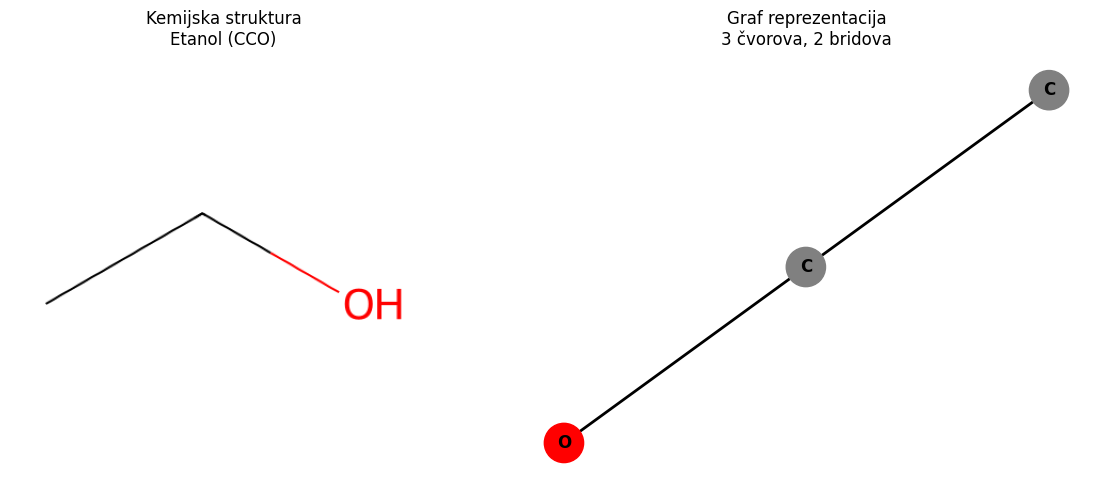

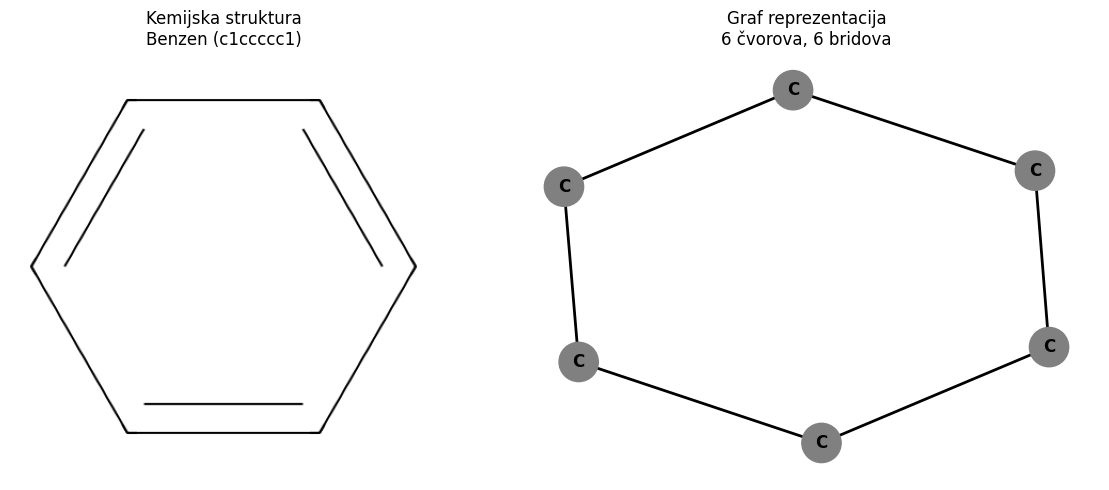

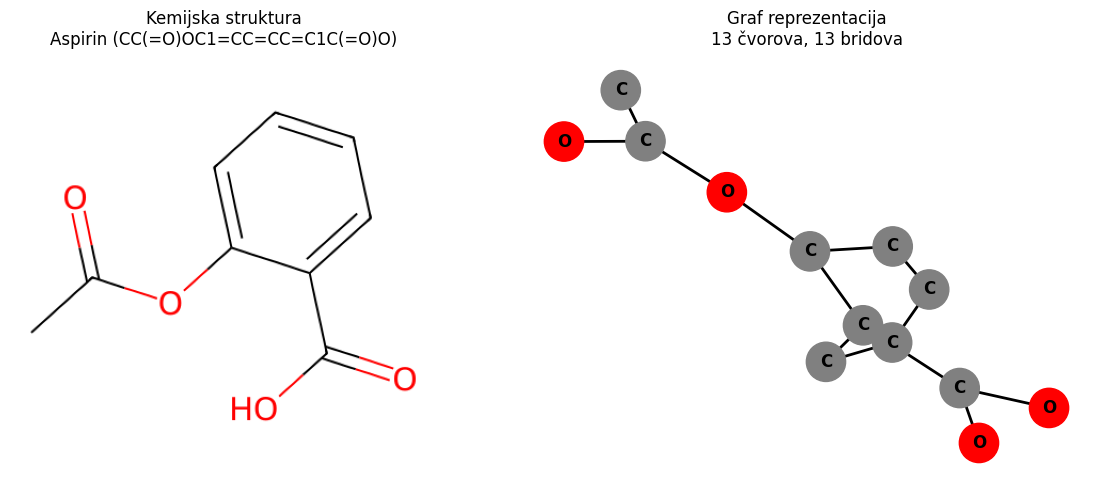

In [ ]:
def draw_molecule_graph(smiles, title=""):
    mol = Chem.MolFromSmiles(smiles)
    graph = from_smiles(smiles)

    G = nx.Graph()
    for i in range(graph.x.size(0)):
        atomski_broj = graph.x[i, 0].item()
        element = Chem.GetPeriodicTable().GetElementSymbol(atomski_broj)
        G.add_node(i, label=element)

    edges_seen = set()
    for i in range(graph.edge_index.size(1)):
        src = graph.edge_index[0, i].item()
        dst = graph.edge_index[1, i].item()
        if (src, dst) not in edges_seen and (dst, src) not in edges_seen:
            bond_type = graph.edge_attr[i, 0].item()
            G.add_edge(src, dst, bond=bond_type)
            edges_seen.add((src, dst))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    img = Draw.MolToImage(mol, size=(400, 400))
    ax1.imshow(img)
    ax1.set_title(f'Kemijska struktura\n{title} ({smiles})')
    ax1.axis('off')

    pos = nx.spring_layout(G, seed=42)
    labels = nx.get_node_attributes(G, 'label')
    colors = {'C': 'gray', 'O': 'red', 'N': 'blue', 'H': 'white', 'S': 'yellow', 'Cl': 'green'}
    node_colors = [colors.get(labels[n], 'purple') for n in G.nodes()]

    nx.draw(G, pos, ax=ax2, labels=labels, node_color=node_colors, node_size=800,
            font_size=12, font_weight='bold', edge_color='black', width=2)
    ax2.set_title(f'Graf reprezentacija\n{len(G.nodes)} čvorova, {len(G.edges)} bridova')

    plt.tight_layout()
    plt.show()

draw_molecule_graph('CCO', 'Etanol')
draw_molecule_graph('c1ccccc1', 'Benzen')
draw_molecule_graph('CC(=O)OC1=CC=CC=C1C(=O)O', 'Aspirin')

## Priprema za treniranje — podjela dataseta

In [ ]:
esol_dataset = MoleculeNet(root='data/', name='ESOL').shuffle()

Processing...
Done!


In [ ]:
train_size = int(len(esol_dataset) * 0.8)
val_size = int(len(esol_dataset) * 0.1)

In [ ]:
train_dataset = esol_dataset[:train_size]
val_dataset = esol_dataset[train_size:train_size + val_size]
test_dataset = esol_dataset[train_size + val_size:]

print(f"Ukupan dataset: {len(esol_dataset)}")
print(f"Train: {len(train_dataset)} ({100 * len(train_dataset) / len(esol_dataset):.1f}%)")
print(f"Validation: {len(val_dataset)} ({100 * len(val_dataset) / len(esol_dataset):.1f}%)")
print(f"Test: {len(test_dataset)} ({100 * len(test_dataset) / len(esol_dataset):.1f}%)")

Ukupan dataset: 1128
Train: 902 (80.0%)
Validation: 112 (9.9%)
Test: 114 (10.1%)


## DataLoader — grupiranje molekula u batcheve

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

batch = next(iter(train_loader))
print(f"Batch sadrži {batch.num_graphs} molekula")
print(f"Ukupan broj atoma u batchu: {batch.x.size(0)}")
print(f"Ukupan broj veza u batchu: {batch.edge_index.size(1)}")
print(f"Oblik batch atributa: {batch.batch.shape}")
print(f"\nPrva 3 atoma pripadaju molekuli: {batch.batch[:3].tolist()}")
print(f"Zadnjih 5 atoma pripada molekuli: {batch.batch[-5:].tolist()}")

Batch sadrži 32 molekula
Ukupan broj atoma u batchu: 353
Ukupan broj veza u batchu: 712
Oblik batch atributa: torch.Size([353])

Prva 3 atoma pripadaju molekuli: [0, 0, 0]
Zadnjih 5 atoma pripada molekuli: [31, 31, 31, 31, 31]
